In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

DB_PATH = "Database/bluestock_mf.db"

conn = sqlite3.connect(DB_PATH)

print("Database connected successfully")

Database connected successfully


In [3]:
print(conn)

In [5]:
tables = pd.read_sql("""
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
""", conn)

tables

,name
0,dim_fund
1,fact_aum
2,fact_benchmark
3,fact_category_inflows
4,fact_folio_count
5,fact_nav
6,fact_performance
7,fact_portfolio
8,fact_sip_inflows
9,fact_transactions


In [6]:
tables = pd.read_sql("""
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
""", conn)

tables

,name
0,dim_fund
1,fact_aum
2,fact_benchmark
3,fact_category_inflows
4,fact_folio_count
5,fact_nav
6,fact_performance
7,fact_portfolio
8,fact_sip_inflows
9,fact_transactions


In [7]:
nav_columns = pd.read_sql("""
    PRAGMA table_info(fact_nav)
""", conn)

nav_columns

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,date,TEXT,0,None,0
2,2,nav,FLOAT,0,None,0


In [8]:
nav = pd.read_sql("""
    SELECT
        amfi_code,
        date,
        nav
    FROM fact_nav
    ORDER BY amfi_code, date
""", conn)

print("NAV data loaded successfully")
print("Rows:", len(nav))
print("Columns:", nav.columns.tolist())

NAV data loaded successfully
Rows: 46000
Columns: ['amfi_code', 'date', 'nav']


In [9]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

print("Daily returns calculated successfully")
print("Rows:", len(nav))
print("Missing returns:", nav["daily_return"].isna().sum())

Daily returns calculated successfully
Rows: 46000
Missing returns: 40


In [10]:

first_fund = nav["amfi_code"].iloc[0]

returns = nav.loc[
    nav["amfi_code"] == first_fund,
    "daily_return"
].dropna()

var_95 = returns.quantile(0.05)

print("AMFI Code:", first_fund)
print("Number of returns:", len(returns))
print("VaR (95%):", var_95)

AMFI Code: 100016
Number of returns: 1149
VaR (95%): -0.014363639988111142


In [11]:
cvar_95 = returns[returns <= var_95].mean()

print("VaR (95%):", var_95)
print("CVaR (95%):", cvar_95)


VaR (95%): -0.014363639988111142
CVaR (95%): -0.01806020763217176


In [12]:
var_cvar_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var_95 = returns.quantile(0.05)

    cvar_95 = returns[returns <= var_95].mean()

    var_cvar_results.append({
        "amfi_code": amfi_code,
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "observations": len(returns)
    })

var_cvar = pd.DataFrame(var_cvar_results)

print("VaR & CVaR calculated successfully")
print("Number of funds:", len(var_cvar))

VaR & CVaR calculated successfully
Number of funds: 40


In [14]:
fund_columns = pd.read_sql("""
    PRAGMA table_info(dim_fund)
""", conn)

fund_columns

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,fund_house,TEXT,0,None,0
2,2,scheme_name,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,sub_category,TEXT,0,None,0
5,5,plan,TEXT,0,None,0
6,6,launch_date,TEXT,0,None,0
7,7,benchmark,TEXT,0,None,0
8,8,expense_ratio_pct,FLOAT,0,None,0
9,9,exit_load_pct,FLOAT,0,None,0


In [15]:
fund_columns = pd.read_sql("""
    PRAGMA table_info(dim_fund)
""", conn)

fund_columns

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,fund_house,TEXT,0,None,0
2,2,scheme_name,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,sub_category,TEXT,0,None,0
5,5,plan,TEXT,0,None,0
6,6,launch_date,TEXT,0,None,0
7,7,benchmark,TEXT,0,None,0
8,8,expense_ratio_pct,FLOAT,0,None,0
9,9,exit_load_pct,FLOAT,0,None,0


In [16]:
fund_columns

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,fund_house,TEXT,0,None,0
2,2,scheme_name,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,sub_category,TEXT,0,None,0
5,5,plan,TEXT,0,None,0
6,6,launch_date,TEXT,0,None,0
7,7,benchmark,TEXT,0,None,0
8,8,expense_ratio_pct,FLOAT,0,None,0
9,9,exit_load_pct,FLOAT,0,None,0


In [17]:
funds = pd.read_sql("""
    SELECT
        amfi_code,
        scheme_name,
        fund_house,
        category,
        sub_category,
        risk_category
    FROM dim_fund
""", conn)

print("Fund information loaded successfully")
print("Number of funds:", len(funds))

Fund information loaded successfully
Number of funds: 40


In [18]:
var_cvar_report = var_cvar.merge(
    funds,
    on="amfi_code",
    how="left"
)

print("VaR/CVaR report created successfully")
print("Rows:", len(var_cvar_report))

VaR/CVaR report created successfully
Rows: 40


In [19]:
var_cvar_report[
    [
        "amfi_code",
        "scheme_name",
        "category",
        "risk_category",
        "VaR_95",
        "CVaR_95"
    ]
].head(10)

,amfi_code,scheme_name,category,risk_category,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Moderate,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,Debt,Low,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,Moderate,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,-0.026021,-0.032459
5,101208,ABSL Liquid Fund - Regular - Growth,Debt,Low,-0.000269,-0.000422
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,Equity,Moderate,-0.012613,-0.015490
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,High,-0.019220,-0.023251
8,102887,UTI Flexi Cap Fund - Regular - Growth,Equity,Moderately High,-0.015232,-0.019411
9,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,Moderate,-0.013954,-0.017619


In [20]:
import os

os.makedirs("Reports", exist_ok=True)

var_cvar_report.to_csv(
    "Reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


In [21]:
rolling_data = nav.copy()

rolling_data["rolling_mean"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

rolling_data["rolling_std"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

rolling_data["rolling_sharpe"] = (
    rolling_data["rolling_mean"]
    / rolling_data["rolling_std"]
    * np.sqrt(252)
)

print("Rolling 90-day Sharpe calculated successfully")

Rolling 90-day Sharpe calculated successfully


In [22]:
rolling_data = nav.copy()

rolling_data["rolling_mean"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).mean())
)

rolling_data["rolling_std"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(lambda x: x.rolling(90).std())
)

rolling_data["rolling_sharpe"] = (
    rolling_data["rolling_mean"]
    / rolling_data["rolling_std"]
    * np.sqrt(252)
)

print("Rolling 90-day Sharpe calculated successfully")

Rolling 90-day Sharpe calculated successfully


In [23]:
rolling_data[
    [
        "amfi_code",
        "date",
        "daily_return",
        "rolling_sharpe"
    ]
].tail(10)

,amfi_code,date,daily_return,rolling_sharpe
45990,149324,2026-05-18,-0.000073,2.008546
45991,149324,2026-05-19,-0.002220,1.790543
45992,149324,2026-05-20,-0.001494,2.064489
45993,149324,2026-05-21,0.005423,2.138907
45994,149324,2026-05-22,-0.025133,1.615362
45995,149324,2026-05-25,0.012106,2.042795
45996,149324,2026-05-26,-0.004138,2.064950
45997,149324,2026-05-27,-0.008480,1.952646
45998,149324,2026-05-28,-0.028093,1.406239
45999,149324,2026-05-29,-0.003335,1.262776


In [24]:
rolling_data[
    [
        "amfi_code",
        "date",
        "daily_return",
        "rolling_sharpe"
    ]
].tail(10)

,amfi_code,date,daily_return,rolling_sharpe
45990,149324,2026-05-18,-0.000073,2.008546
45991,149324,2026-05-19,-0.002220,1.790543
45992,149324,2026-05-20,-0.001494,2.064489
45993,149324,2026-05-21,0.005423,2.138907
45994,149324,2026-05-22,-0.025133,1.615362
45995,149324,2026-05-25,0.012106,2.042795
45996,149324,2026-05-26,-0.004138,2.064950
45997,149324,2026-05-27,-0.008480,1.952646
45998,149324,2026-05-28,-0.028093,1.406239
45999,149324,2026-05-29,-0.003335,1.262776


In [25]:
key_funds = [
    100016,   
    101207,   
    102885,   
    118632,   
    149324
]

print("Selected funds:", key_funds)

Selected funds: [100016, 101207, 102885, 118632, 149324]


In [26]:
key_fund_names = funds[
    funds["amfi_code"].isin(key_funds)
][
    ["amfi_code", "scheme_name"]
]

key_fund_names

,amfi_code,scheme_name
5,100016,HDFC Top 100 Fund - Regular Plan - Growth
15,118632,Nippon India Large Cap Fund - Regular - Growth
29,101207,ABSL Small Cap Fund - Regular - Growth
31,102885,UTI Nifty 50 Index Fund - Regular - Growth
39,149324,DSP Small Cap Fund - Regular - Growth


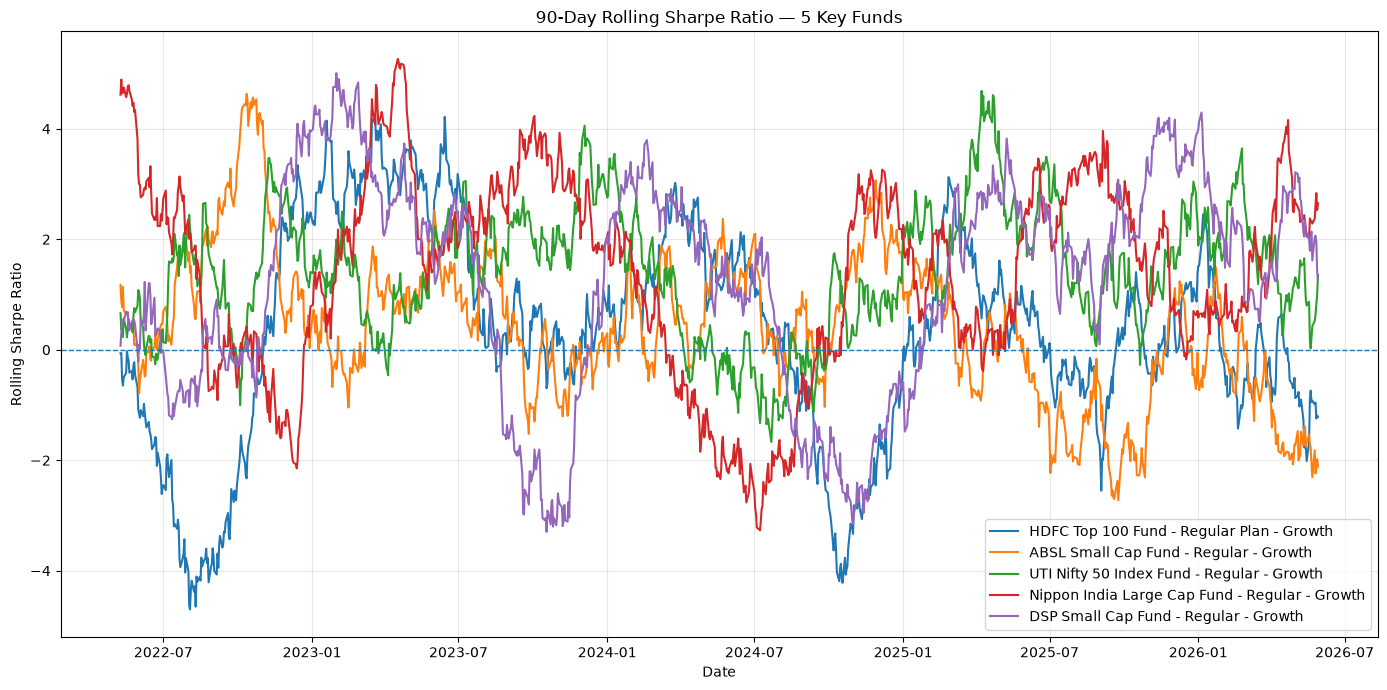

rolling_sharpe_chart.png saved successfully


In [27]:
plt.figure(figsize=(14, 7))

for amfi_code in key_funds:
    fund_data = rolling_data[
        rolling_data["amfi_code"] == amfi_code
    ]

    fund_name = funds.loc[
        funds["amfi_code"] == amfi_code,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_sharpe"],
        label=fund_name
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("90-Day Rolling Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "Reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("rolling_sharpe_chart.png saved successfully")

In [28]:
transaction_columns = pd.read_sql("""
    PRAGMA table_info(fact_transactions)
""", conn)

transaction_columns

,cid,name,type,notnull,dflt_value,pk
0,0,investor_id,TEXT,0,None,0
1,1,transaction_date,DATETIME,0,None,0
2,2,amfi_code,BIGINT,0,None,0
3,3,transaction_type,TEXT,0,None,0
4,4,amount_inr,BIGINT,0,None,0
5,5,state,TEXT,0,None,0
6,6,city,TEXT,0,None,0
7,7,city_tier,TEXT,0,None,0
8,8,age_group,TEXT,0,None,0
9,9,gender,TEXT,0,None,0


In [29]:
transactions = pd.read_sql("""
    SELECT
        investor_id,
        transaction_date,
        amfi_code,
        transaction_type,
        amount_inr
    FROM fact_transactions
""", conn)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print("Transaction data loaded successfully")
print("Rows:", len(transactions))
print("Unique investors:", transactions["investor_id"].nunique())

Transaction data loaded successfully
Rows: 32778
Unique investors: 5000


In [30]:
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"]
    .dt.year
)

print("Investor cohorts created successfully")
print("Number of investors:", len(first_transaction))

first_transaction.head()

Investor cohorts created successfully
Number of investors: 5000


,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [31]:
transactions_cohort = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

print("Cohort information added to transactions")
print("Rows:", len(transactions_cohort))

Cohort information added to transactions
Rows: 32778


In [32]:
sip_transactions = transactions_cohort[
    transactions_cohort["transaction_type"].str.upper() == "SIP"
].copy()

cohort_sip_analysis = (
    sip_transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        sip_transactions=("amount_inr", "count"),
        investors=("investor_id", "nunique")
    )
    .reset_index()
)

cohort_sip_analysis

,cohort_year,avg_sip_amount,total_invested,sip_transactions,investors
0,2024,10996.885825,214978121,19549,4624
1,2025,13505.209581,2255370,167,138


In [33]:
top_fund = (
    sip_transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="sip_count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year", "sip_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_fund = top_fund.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund[
    ["cohort_year", "scheme_name", "sip_count"]
]

,cohort_year,scheme_name,sip_count
0,2024,ICICI Pru Bluechip Fund - Direct - Growth,536
1,2025,SBI Small Cap Fund - Direct Plan - Growth,8


In [34]:
cohort_report = cohort_sip_analysis.merge(
    top_fund[
        ["cohort_year", "scheme_name", "sip_count"]
    ],
    on="cohort_year",
    how="left"
)

cohort_report = cohort_report.rename(
    columns={
        "scheme_name": "top_fund",
        "sip_count": "top_fund_sip_count"
    }
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,sip_transactions,investors,top_fund,top_fund_sip_count
0,2024,10996.885825,214978121,19549,4624,ICICI Pru Bluechip Fund - Direct - Growth,536
1,2025,13505.209581,2255370,167,138,SBI Small Cap Fund - Direct Plan - Growth,8


In [35]:
cohort_report.to_csv(
    "Reports/investor_cohort_report.csv",
    index=False
)

print("Investor cohort report saved successfully")

Investor cohort report saved successfully


In [36]:
sip_only = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip_only = sip_only.sort_values(
    ["investor_id", "transaction_date"]
)

print("SIP transactions:", len(sip_only))
print("SIP investors:", sip_only["investor_id"].nunique())

SIP transactions: 19716
SIP investors: 4762


In [37]:
sip_counts = (
    sip_only
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
].copy()

print("Investors with 6+ SIP transactions:",
      len(eligible_investors))

eligible_investors.head()

Investors with 6+ SIP transactions: 1362


,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [38]:
sip_eligible = sip_only[
    sip_only["investor_id"].isin(
        eligible_investors["investor_id"]
    )
].copy()

sip_eligible = sip_eligible.sort_values(
    ["investor_id", "transaction_date"]
)

sip_eligible["gap_days"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

print("SIP date gaps calculated successfully")

SIP date gaps calculated successfully


In [39]:
sip_continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days
0,INV000004,6,85.400000
1,INV000008,6,70.400000
2,INV000010,6,64.800000
3,INV000011,7,40.166667
4,INV000012,8,57.000000


In [40]:
sip_continuity["continuity_status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "at-risk",
    "continuous"
)

print("SIP continuity status assigned successfully")

sip_continuity.head()

SIP continuity status assigned successfully


,investor_id,sip_count,avg_gap_days,continuity_status
0,INV000004,6,85.400000,at-risk
1,INV000008,6,70.400000,at-risk
2,INV000010,6,64.800000,at-risk
3,INV000011,7,40.166667,at-risk
4,INV000012,8,57.000000,at-risk


In [41]:
continuity_summary = (
    sip_continuity["continuity_status"]
    .value_counts()
    .reset_index()
)

continuity_summary.columns = [
    "continuity_status",
    "investor_count"
]

continuity_summary["percentage"] = (
    continuity_summary["investor_count"]
    / len(sip_continuity)
    * 100
)

continuity_summary

,continuity_status,investor_count,percentage
0,at-risk,1332,97.797357
1,continuous,30,2.202643


In [42]:
sip_continuity.to_csv(
    "Reports/sip_continuity_report.csv",
    index=False
)

print("SIP continuity report saved successfully")

SIP continuity report saved successfully


In [43]:
performance_columns = pd.read_sql("""
    PRAGMA table_info(fact_performance)
""", conn)

performance_columns

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,scheme_name,TEXT,0,None,0
2,2,fund_house,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,plan,TEXT,0,None,0
5,5,return_1yr_pct,FLOAT,0,None,0
6,6,return_3yr_pct,FLOAT,0,None,0
7,7,return_5yr_pct,FLOAT,0,None,0
8,8,benchmark_3yr_pct,FLOAT,0,None,0
9,9,alpha,FLOAT,0,None,0


In [44]:
fund_performance = pd.read_sql("""
    SELECT
        amfi_code,
        scheme_name,
        category,
        risk_grade,
        sharpe_ratio
    FROM fact_performance
""", conn)

print("Fund performance data loaded successfully")
print("Number of funds:", len(fund_performance))

fund_performance.head()

Fund performance data loaded successfully
Number of funds: 40


,amfi_code,scheme_name,category,risk_grade,sharpe_ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,Moderate,0.88
1,119552,SBI Bluechip Fund - Direct Plan - Growth,Large Cap,Moderate,0.81
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,Very High,0.94
3,119599,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,Very High,0.93
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,Low,1.52


In [45]:
def recommend_funds(risk_appetite):
    risk_appetite = risk_appetite.strip().title()

    valid_risks = ["Low", "Moderate", "High"]

    if risk_appetite not in valid_risks:
        print("Invalid risk appetite.")
        print("Choose: Low, Moderate, or High")
        return None

    recommendations = (
        fund_performance[
            fund_performance["risk_grade"] == risk_appetite
        ]
        .sort_values("sharpe_ratio", ascending=False)
        .head(3)
        .reset_index(drop=True)
    )

    recommendations.index = recommendations.index + 1

    return recommendations[
        [
            "amfi_code",
            "scheme_name",
            "category",
            "risk_grade",
            "sharpe_ratio"
        ]
    ]


print("Fund recommender created successfully")

Fund recommender created successfully


In [46]:
recommend_funds("Low")

,amfi_code,scheme_name,category,risk_grade,sharpe_ratio
1,120507,ICICI Pru Liquid Fund - Regular - Growth,Liquid,Low,7.68
2,120844,Kotak Liquid Fund - Regular - Growth,Liquid,Low,6.18
3,101208,ABSL Liquid Fund - Regular - Growth,Liquid,Low,5.14


In [47]:
recommend_funds("Moderate")

,amfi_code,scheme_name,category,risk_grade,sharpe_ratio
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,Moderate,1.06
2,148567,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,Moderate,1.06
3,120504,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,Moderate,1.03


In [48]:
recommend_funds("High")

,amfi_code,scheme_name,category,risk_grade,sharpe_ratio
1,120842,Kotak Emerging Equity Fund - Regular - Growth,Mid Cap,High,0.96
2,120505,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,High,0.95
3,149323,DSP Midcap Fund - Regular - Growth,Mid Cap,High,0.90


In [49]:
recommender_code = '''
import sqlite3
import pandas as pd


DB_PATH = "Database/bluestock_mf.db"


def recommend_funds(risk_appetite):

    risk_appetite = risk_appetite.strip().title()

    valid_risks = ["Low", "Moderate", "High"]

    if risk_appetite not in valid_risks:
        print("Invalid risk appetite.")
        print("Choose: Low, Moderate, or High")
        return None

    conn = sqlite3.connect(DB_PATH)

    funds = pd.read_sql("""
        SELECT
            amfi_code,
            scheme_name,
            category,
            risk_grade,
            sharpe_ratio
        FROM fact_performance
    """, conn)

    conn.close()

    recommendations = (
        funds[
            funds["risk_grade"] == risk_appetite
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
        .reset_index(drop=True)
    )

    recommendations.index = recommendations.index + 1

    return recommendations[
        [
            "amfi_code",
            "scheme_name",
            "category",
            "risk_grade",
            "sharpe_ratio"
        ]
    ]


if __name__ == "__main__":

    risk = input(
        "Enter risk appetite (Low/Moderate/High): "
    )

    result = recommend_funds(risk)

    if result is not None:
        print("\\nTop 3 Recommended Funds:")
        print(result.to_string(index=True))
'''

with open("recommender.py", "w", encoding="utf-8") as f:
    f.write(recommender_code)

print("recommender.py saved successfully")

recommender.py saved successfully


In [50]:
portfolio_columns = pd.read_sql("""
    PRAGMA table_info(fact_portfolio)
""", conn)

portfolio_columns

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,BIGINT,0,None,0
1,1,stock_symbol,TEXT,0,None,0
2,2,stock_name,TEXT,0,None,0
3,3,sector,TEXT,0,None,0
4,4,weight_pct,FLOAT,0,None,0
5,5,market_value_cr,FLOAT,0,None,0
6,6,current_price_inr,FLOAT,0,None,0
7,7,portfolio_date,TEXT,0,None,0


In [51]:
portfolio = pd.read_sql("""
    SELECT
        amfi_code,
        sector,
        weight_pct
    FROM fact_portfolio
""", conn)

print("Portfolio data loaded successfully")
print("Rows:", len(portfolio))
print("Funds:", portfolio["amfi_code"].nunique())

portfolio.head()

Portfolio data loaded successfully
Rows: 322
Funds: 34


,amfi_code,sector,weight_pct
0,119551,Utilities,13.85
1,119551,Banking,11.19
2,119551,Diversified,9.90
3,119551,Pharma,4.76
4,119551,Paints,10.25


In [53]:
hhi_report = hhi_report.merge(
    funds[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

hhi_report = hhi_report.sort_values(
    "HHI",
    ascending=False
).reset_index(drop=True)

hhi_report.head(10)

,amfi_code,HHI,scheme_name,category
0,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Equity
1,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
2,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
3,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,Equity
4,149323,0.241077,DSP Midcap Fund - Regular - Growth,Equity
5,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth,Equity
6,118635,0.237497,Nippon India ETF Nifty 50 BeES,Equity
7,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth,Equity
8,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
9,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity


In [54]:
equity_hhi = hhi_report[
    hhi_report["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
].copy()

equity_hhi = equity_hhi.sort_values(
    "HHI",
    ascending=False
).reset_index(drop=True)

print("Equity funds in HHI analysis:", len(equity_hhi))

equity_hhi.head(10)

Equity funds in HHI analysis: 34


,amfi_code,HHI,scheme_name,category
0,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Equity
1,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
2,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
3,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,Equity
4,149323,0.241077,DSP Midcap Fund - Regular - Growth,Equity
5,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth,Equity
6,118635,0.237497,Nippon India ETF Nifty 50 BeES,Equity
7,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth,Equity
8,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
9,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity


In [55]:
equity_hhi.to_csv(
    "Reports/sector_hhi_report.csv",
    index=False
)

print("Sector HHI report saved successfully")

Sector HHI report saved successfully


# Advanced Analytics — Key Business Insights

## 1. Risk and VaR Insight

The Historical VaR analysis shows meaningful differences in downside risk across mutual fund schemes. Among the analysed funds, ABSL Small Cap Fund has a relatively high downside risk, with a 95% VaR of approximately -2.60% and CVaR of approximately -3.25%. This indicates that during adverse trading days, losses can be significantly larger than the normal daily fluctuation.

## 2. Investor Cohort Insight

The 2024 investor cohort is the dominant contributor to total SIP investment, with 4,624 investors and approximately ₹214.98 million invested through SIP transactions. The 2025 cohort has a higher average SIP amount of approximately ₹13,505 compared with approximately ₹10,997 for the 2024 cohort, indicating higher average contribution levels among newer investors.

## 3. SIP Continuity Insight

Among investors with at least 6 SIP transactions, approximately 97.80% were classified as at-risk because their average gap between SIP transactions exceeded 35 days. Only approximately 2.20% were classified as continuous. This indicates a potential opportunity for investor-retention and SIP-continuity initiatives.

## 4. Fund Performance and Risk Insight

The fund recommender shows that the highest Sharpe ratios vary significantly by risk category. Among Low-risk funds, ICICI Pru Liquid Fund has the highest Sharpe ratio of 7.68. For Moderate-risk funds, HDFC Top 100 Fund and Mirae Asset Large Cap Fund have Sharpe ratios of approximately 1.06. Among High-risk funds, Kotak Emerging Equity Fund leads with a Sharpe ratio of approximately 0.96.

## 5. Portfolio Concentration Insight

Sector HHI analysis shows differences in portfolio concentration across the 34 equity funds analysed. Axis Bluechip Fund has the highest sector HHI of approximately 0.297, indicating relatively higher sector concentration. Lower HHI values would indicate greater diversification across sectors and potentially lower concentration risk.

In [56]:
import os

required_files = [
    "Advanced_Analytics.ipynb",
    "recommender.py",
    "Reports/var_cvar_report.csv",
    "Reports/investor_cohort_report.csv",
    "Reports/sip_continuity_report.csv",
    "Reports/sector_hhi_report.csv",
    "Reports/rolling_sharpe_chart.png"
]

for file in required_files:
    if os.path.exists(file):
        print("✅ FOUND:", file)
    else:
        print("❌ MISSING:", file)

✅ FOUND: Advanced_Analytics.ipynb
✅ FOUND: recommender.py
✅ FOUND: Reports/var_cvar_report.csv
✅ FOUND: Reports/investor_cohort_report.csv
✅ FOUND: Reports/sip_continuity_report.csv
✅ FOUND: Reports/sector_hhi_report.csv
✅ FOUND: Reports/rolling_sharpe_chart.png
